In [ ]:
# =========================================
# Step 1: Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from ipywidgets import widgets, Button, VBox, Output
from IPython.display import display, clear_output

In [ ]:
# =========================================
# Step 2: Load Dataset
# =========================================
df = pd.read_csv("/content/CC GENERAL.csv")
print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
# =========================================
# Step 3: Preprocessing
# =========================================
X = df.drop("CUST_ID", axis=1)

# Fill missing values with mean
X.fillna(X.mean(), inplace=True)

# Standardize features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

print("Data shape after scaling:", scaled_data.shape)
X.head()


Data shape after scaling: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


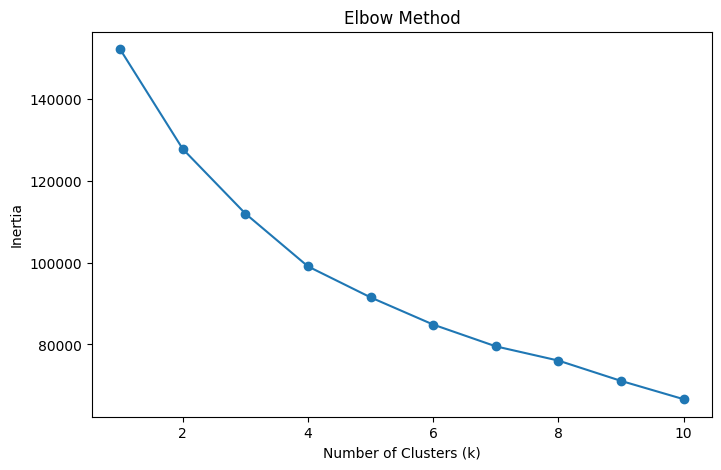

In [ ]:
# =========================================
# Step 4: Elbow Method to Choose k
# =========================================
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [ ]:
# =========================================
# Step 5: Train KMeans
# =========================================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add clusters to df
df["Cluster"] = clusters
print("Cluster assignment for first few customers:")
df.head()


Cluster assignment for first few customers:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,3
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


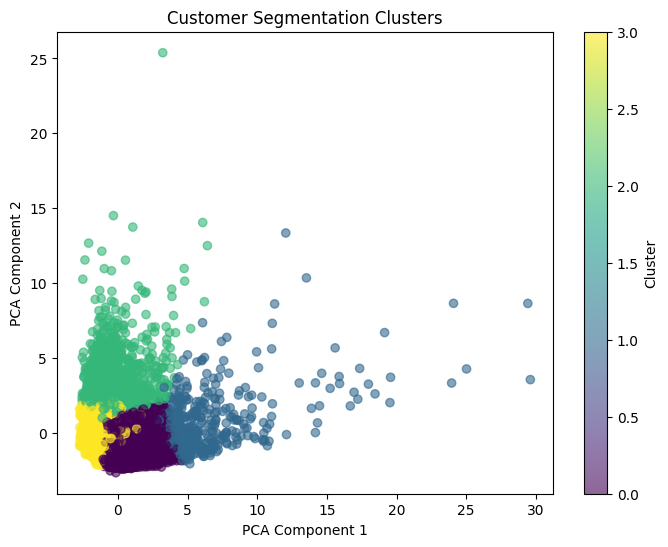

In [ ]:

032++# =========================================
# Step 6: Visualize Clusters
# =========================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap="viridis", alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation Clusters")
plt.colorbar(label="Cluster")
plt.show()


Cluster Summary (Average values per cluster):
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0         894.907458           0.934734  1236.178934        593.974874   
1        3551.153761           0.986879  7681.620098       5095.878826   
2        4602.462714           0.968415   501.896219        320.373681   
3        1011.751528           0.789871   269.973466        209.853863   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    642.478274    210.570626             0.885165   
1                   2587.208264    653.638891             0.946418   
2                    181.607404   4520.724309             0.287731   
3                     60.386625    595.759339             0.170146   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster        

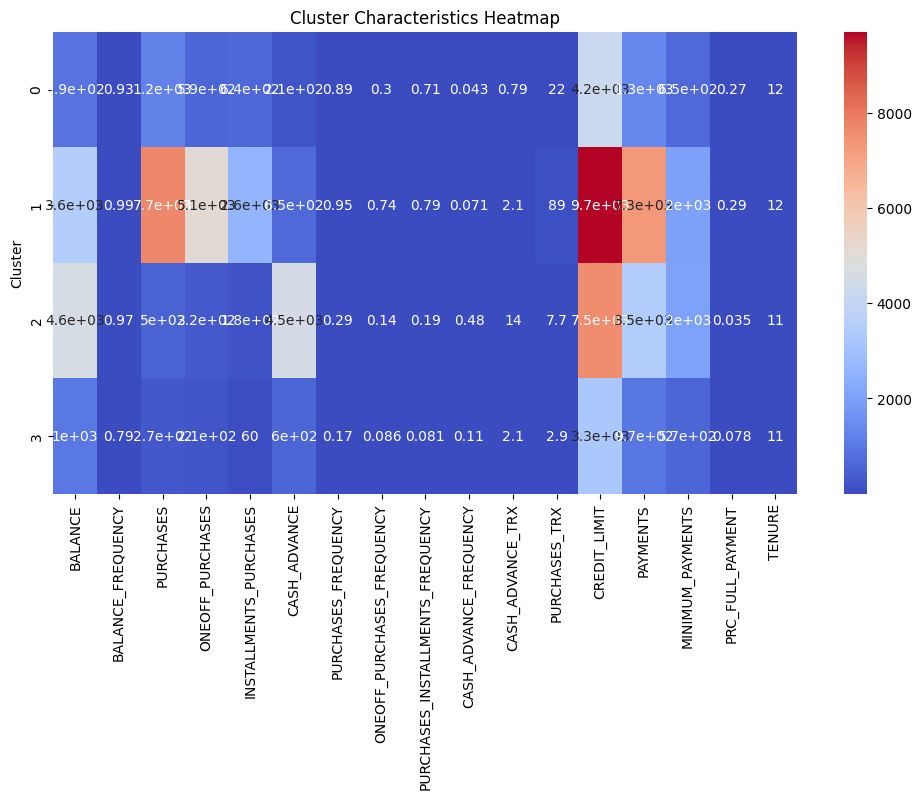

In [ ]:
# =========================================
# Step 7: Cluster Analysis
# =========================================

# Select only numeric columns for analysis
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'Cluster' itself from numeric_cols
if "Cluster" in numeric_cols:
    numeric_cols.remove("Cluster")

# Compute mean values per cluster
cluster_summary = df.groupby("Cluster")[numeric_cols].mean()
print("Cluster Summary (Average values per cluster):")
print(cluster_summary)

# Heatmap visualization
plt.figure(figsize=(12,6))
sns.heatmap(cluster_summary, cmap="coolwarm", annot=True)
plt.title("Cluster Characteristics Heatmap")
plt.show()


In [ ]:
# =========================================
# Step 8: Business Interpretation
# =========================================
interpretations = {}
for cluster_id, row in cluster_summary.iterrows():
    desc = []
    desc.append("High Balance Users" if row["BALANCE"] > cluster_summary["BALANCE"].mean() else "Low Balance Users")
    desc.append("High Spenders" if row["PURCHASES"] > cluster_summary["PURCHASES"].mean() else "Low Spenders")
    desc.append("High Credit Limit" if row["CREDIT_LIMIT"] > cluster_summary["CREDIT_LIMIT"].mean() else "Low Credit Limit")
    desc.append("Good Payers" if row["PAYMENTS"] > cluster_summary["PAYMENTS"].mean() else "Low/Irregular Payers")
    interpretations[cluster_id] = ", ".join(desc)

print("Business-Level Cluster Interpretations:")
for cluster, meaning in interpretations.items():
    print(f"Cluster {cluster}: {meaning}")


Business-Level Cluster Interpretations:
Cluster 0: Low Balance Users, Low Spenders, Low Credit Limit, Low/Irregular Payers
Cluster 1: High Balance Users, High Spenders, High Credit Limit, Good Payers
Cluster 2: High Balance Users, Low Spenders, High Credit Limit, Good Payers
Cluster 3: Low Balance Users, Low Spenders, Low Credit Limit, Low/Irregular Payers


In [ ]:
# =========================================
# Step 9: Interactive Widget for Customer
# =========================================
out = Output()
features = X.columns.tolist()

# Widgets
cust_id_widget = widgets.Text(
    description="Customer ID:",
    placeholder="Enter ID or leave blank for new customer"
)
submit_button = Button(description="Check Customer", button_style='info')
predict_button = Button(description="Predict Cluster", button_style='success')

# Create widgets for each feature
feature_widgets = {
    f: widgets.FloatText(description=f, placeholder="Leave blank for mean") for f in features
}

# Box for new customer input
new_customer_box = VBox(list(feature_widgets.values()))
new_customer_box.layout.display = "none"  # Hidden initially

# ----------------------------
# Function: Handle existing or new customer
# ----------------------------
def on_submit_clicked(b):
    with out:
        clear_output()
        cust_id = cust_id_widget.value.strip()

        if cust_id != "" and cust_id in df["CUST_ID"].astype(str).values:
            # ✅ Existing Customer Found
            row = df[df["CUST_ID"].astype(str) == cust_id].iloc[0]
            cluster = row["Cluster"]
            meaning = interpretations.get(cluster, "No interpretation available")

            print("✅ Existing Customer Found!")
            print(f"Customer ID: {cust_id}")
            print(f"Cluster: {cluster}")
            print(f"Business Meaning: {meaning}")
            print("\nCustomer details:")
            display(row.to_frame().T)

            # Hide new customer fields
            new_customer_box.layout.display = "none"

        else:
            # ⚡ New customer detected
            print("⚡ New customer detected. Enter details below (leave blank for mean values):")
            new_customer_box.layout.display = "flex"

# ----------------------------
# Function: Predict for new customer
# ----------------------------
def predict_new_customer(b):
    global df # Declare df as global to modify the original DataFrame
    with out:
        clear_output()

        new_customer_data = {}
        for f, widget in feature_widgets.items():
            val = widget.value
            # If user leaves blank (value = 0.0 by default), use mean of that feature
            if val == 0.0:
                # Use mean from the original X DataFrame before scaling
                new_customer_data[f] = X[f].mean()
            else:
                new_customer_data[f] = val

        # Convert to DataFrame and scale
        new_data_df = pd.DataFrame([new_customer_data])
        # Ensure order of columns is the same as X before scaling
        new_data_df = new_data_df[X.columns]
        scaled_data = scaler.transform(new_data_df)

        # Predict cluster
        cluster = kmeans.predict(scaled_data)[0]
        meaning = interpretations.get(cluster, "No interpretation available")

        # Add the predicted cluster to the new customer DataFrame
        new_data_df["Cluster"] = cluster

        # Generate a unique CUST_ID for the new customer
        # A simple approach: use the next available index as ID
        new_customer_id = f"C{len(df) + 1:05d}"
        new_data_df.insert(0, "CUST_ID", new_customer_id)


        # Append the new customer DataFrame to the main DataFrame
        df = pd.concat([df, new_data_df], ignore_index=True)

        print("🧑 New Customer Prediction:")
        print(f"Customer ID: {new_customer_id}")
        print(f"Cluster: {cluster}")
        print(f"Business Meaning: {meaning}")
        print(f"New customer added to DataFrame.")
        print("\nEntered details:")
        display(new_data_df)

        # Save the updated dataframe
        save_clustered_data(df)


# ----------------------------
# Button click bindings
# ----------------------------
submit_button.on_click(on_submit_clicked)
predict_button.on_click(predict_new_customer)

# ----------------------------
# Display the full interactive layout
# ----------------------------
display(VBox([
    cust_id_widget,
    submit_button,
    new_customer_box,
    predict_button,
    out
]))

In [ ]:
# =========================================
# Step 10: Function to Save Clustered Dataset
# =========================================
def save_clustered_data(df):
    """Saves the DataFrame with cluster assignments to a CSV file."""
    df.to_csv("clustered_customers.csv", index=False)
    print("Clustered dataset saved as 'clustered_customers.csv'")

# Call the function to save the current state of the DataFrame
save_clustered_data(df)

Clustered dataset saved as 'clustered_customers.csv'
